# What We Did in This Notebook

This notebook is all about studying how winning awards affects researchers' careers, especially in terms of citations and publications. We're looking at data from OpenAlex to see if junior researchers (who got awards) perform differently compared to senior ones (who didn't, but are similar in other ways).

## Step 1: Setting Up and Loading Data
- We imported some useful libraries like pandas, numpy, and matplotlib for data handling and plotting.
- Loaded two main datasets: one with matched pairs of junior and senior researchers (`pairs`), and another with detailed profiles of all researchers (`profiles`).

## Step 2: Preparing the Data
- Parsed the yearly counts from JSON in the profiles to create a "long" format DataFrame. This gives us works and citations for each author per year.
- Calculated relative years (like -5 to +5 around the award year) and kept only data within that window.

## Step 3: Calculating Pre- and Post-Award Averages
- For each author, computed average citations and works in the 5 years before and after the award.
- Built a summary table for all authors with these averages.

## Step 4: Computing "Lift" and Filtering
- "Lift" is the ratio of post-award to pre-award activity (citations or works). We only kept authors who had some pre-award data to avoid weird results.
- Saved the valid authors and pairs data to CSV files.

## Step 5: Analyzing Missing Data
- Checked why some authors had missing data (e.g., no pre-award activity or sparse records).

## Step 6: Summarizing by Group
- Grouped authors by treatment (junior vs. senior) and calculated medians for lift, plus means for pre/post citations.

## Step 7: Statistical Tests
- Used Wilcoxon tests to check if the lift differences between juniors and seniors are significant.

## Step 8: Visualizing Results
- Plotted trajectories: How citations and publications change over time relative to the award, with medians and IQR for juniors and seniors.
- Made boxplots showing the distribution of lift values, capped at certain levels for clarity.

Overall, we're trying to see if awards boost junior researchers' output more than seniors', using matched pairs to make it fair. The results show some differences, especially in publications! 📊

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

ROOT          = Path("..")
DATA_MATCHED  = ROOT / "data" / "matched"
DATA_PROFILES = ROOT / "data" / "profiles"
DATA_FIGURES  = ROOT / "data" / "figures"

In [2]:
pairs    = pd.read_csv(DATA_MATCHED  / "matched_pairs_clean.csv")
profiles = pd.read_csv(DATA_PROFILES / "all_matched_profiles.csv")

print("matched_pairs:       ", pairs.shape)
print("all_matched_profiles:", profiles.shape)
print("\nprofiles sample:")
print(profiles.head(3))

matched_pairs:        (345, 9)
all_matched_profiles: (1206, 8)

profiles sample:
                          author_id       author_name  works_count  \
0  https://openalex.org/A5014823249      Jincheng Mei           29   
1  https://openalex.org/A5069646529  Adhiguna Kuncoro           35   
2  https://openalex.org/A5032195981      Sang-Gyun An            8   

   cited_by_count                                     counts_by_year  \
0             244  [{"year": 2014, "works_count": 3, "oa_works_co...   
1            1578  [{"year": 2016, "works_count": 4, "oa_works_co...   
2             131  [{"year": 2017, "works_count": 2, "oa_works_co...   

   award_year conference  treatment  
0        2018       AAAI          1  
1        2018        ACL          1  
2        2018        CHI          1  


In [3]:
import ast

def parse_counts(row):
    """Expand the counts_by_year JSON list into one row per year."""
    try:
        entries = ast.literal_eval(row["counts_by_year"])
    except Exception:
        return pd.DataFrame()
    rows = []
    for e in entries:
        rows.append({
            "author_id"  : row["author_id"],
            "treatment"  : row["treatment"],
            "conference" : row["conference"],
            "award_year" : row["award_year"],
            "cal_year"   : int(e["year"]),
            "works"      : int(e.get("works_count", 0)),
            "citations"  : int(e.get("cited_by_count", 0)),
        })
    return pd.DataFrame(rows)

long = pd.concat(
    [parse_counts(r) for _, r in profiles.iterrows()],
    ignore_index=True
)

# Compute relative year
long["rel_year"] = long["cal_year"] - long["award_year"]

# Keep ±10 window
long = long[long["rel_year"].between(-10, 10)]

print("Long format shape:", long.shape)
print("rel_year range:", long["rel_year"].min(), "→", long["rel_year"].max())
print(long.head())


Long format shape: (14149, 8)
rel_year range: -10 → 10
                          author_id  treatment conference  award_year  \
0  https://openalex.org/A5014823249          1       AAAI        2018   
1  https://openalex.org/A5014823249          1       AAAI        2018   
2  https://openalex.org/A5014823249          1       AAAI        2018   
3  https://openalex.org/A5014823249          1       AAAI        2018   
4  https://openalex.org/A5014823249          1       AAAI        2018   

   cal_year  works  citations  rel_year  
0      2014      3         46        -4  
1      2015      1          2        -3  
2      2016      3         10        -2  
3      2017      1         21        -1  
4      2018      2         20         0  


In [4]:
PRE_WINDOW  = range(-5, 0)   # rel_year -5 to -1
POST_WINDOW = range(1, 6)    # rel_year +1 to +5

def window_avg(df, author_id, window, metric):
    sub = df[(df["author_id"] == author_id) & (df["rel_year"].isin(window))]
    return sub[metric].mean() if len(sub) > 0 else np.nan

# Build per-author summary
authors = profiles[["author_id", "author_name", "treatment", "conference", "award_year"]].copy()

for metric in ["citations", "works"]:
    authors[f"pre_avg_{metric}"]  = authors["author_id"].apply(
        lambda aid: window_avg(long, aid, PRE_WINDOW, metric))
    authors[f"post_avg_{metric}"] = authors["author_id"].apply(
        lambda aid: window_avg(long, aid, POST_WINDOW, metric))

print("Author summary shape:", authors.shape)
print(authors[["author_name","treatment","pre_avg_citations","post_avg_citations"]].head(6))

Author summary shape: (1206, 9)
        author_name  treatment  pre_avg_citations  post_avg_citations
0      Jincheng Mei          1              19.75                48.0
1  Adhiguna Kuncoro          1             319.00               145.6
2      Sang-Gyun An          1              27.00                15.0
3    Sylvia Simioni          1                NaN                36.0
4      Sean Peacock          1               2.50                17.5
5  Clara Crivellaro          1             141.50                63.4


In [5]:
# ── Proper fix: exclude authors with no pre-award data ────────────────────
# Lift is only meaningful if the author had some pre-award activity
# Authors with pre_avg = 0 get lift = infinity → exclude them

authors_valid = authors[
    (authors["pre_avg_citations"] > 0) &
    (authors["pre_avg_works"] > 0)
].copy()

# Recompute lift without EPSILON trick — denominators are now all > 0
for metric in ["citations", "works"]:
    authors_valid[f"lift_{metric}"] = (
        authors_valid[f"post_avg_{metric}"] /
        authors_valid[f"pre_avg_{metric}"]
    )

print(f"Authors with valid pre-award activity: {len(authors_valid)}/{len(authors)}")
print(f"  Juniors: {(authors_valid['treatment']==1).sum()}")
print(f"  Seniors: {(authors_valid['treatment']==0).sum()}")
print(f"\nlift_citations — median: {authors_valid['lift_citations'].median():.2f}  "
      f"max: {authors_valid['lift_citations'].max():.2f}  "
      f"99th pct: {authors_valid['lift_citations'].quantile(0.99):.2f}")
print(f"lift_works    — median: {authors_valid['lift_works'].median():.2f}  "
      f"max: {authors_valid['lift_works'].max():.2f}  "
      f"99th pct: {authors_valid['lift_works'].quantile(0.99):.2f}")

# Rebuild lookup and pairs_lift
cit_lookup   = authors_valid.drop_duplicates("author_id").set_index("author_id")["lift_citations"].to_dict()
works_lookup = authors_valid.drop_duplicates("author_id").set_index("author_id")["lift_works"].to_dict()

pairs_lift = pairs[["treated_id","control_id","conference","award_year","core_rank"]].copy()
pairs_lift["lift_cit_treated"]   = pairs_lift["treated_id"].map(cit_lookup)
pairs_lift["lift_works_treated"] = pairs_lift["treated_id"].map(works_lookup)
pairs_lift["lift_cit_control"]   = pairs_lift["control_id"].map(cit_lookup)
pairs_lift["lift_works_control"] = pairs_lift["control_id"].map(works_lookup)

pairs_lift = pairs_lift.dropna(subset=["lift_cit_treated","lift_cit_control",
                                        "lift_works_treated","lift_works_control"])

print(f"\nValid pairs after filtering: {len(pairs_lift)}")
print(f"lift_cit_treated  — median: {pairs_lift['lift_cit_treated'].median():.2f}  "
      f"max: {pairs_lift['lift_cit_treated'].max():.2f}")
print(f"lift_works_treated — median: {pairs_lift['lift_works_treated'].median():.2f}  "
      f"max: {pairs_lift['lift_works_treated'].max():.2f}")

# Save
authors_valid.to_csv(DATA_MATCHED / "author_lift.csv", index=False)
pairs_lift.to_csv(DATA_MATCHED / "pairs_lift.csv", index=False)
print("\n✓ author_lift.csv + pairs_lift.csv updated")


Authors with valid pre-award activity: 961/1206
  Juniors: 451
  Seniors: 510

lift_citations — median: 1.77  max: 519.25  99th pct: 139.01
lift_works    — median: 1.70  max: 17.75  99th pct: 10.85

Valid pairs after filtering: 358
lift_cit_treated  — median: 1.55  max: 519.25
lift_works_treated — median: 1.60  max: 17.75

✓ author_lift.csv + pairs_lift.csv updated


In [6]:
nan_pre_only  = authors[authors["pre_avg_citations"].isna()  & authors["post_avg_citations"].notna()]
nan_post_only = authors[authors["post_avg_citations"].isna() & authors["pre_avg_citations"].notna()]
nan_both      = authors[authors["pre_avg_citations"].isna()  & authors["post_avg_citations"].isna()]

print("── NaN breakdown ──")
print(f"  No pre-award data only:   {len(nan_pre_only)}  (career-starters)")
print(f"  No post-award data only:  {len(nan_post_only)}  (recent awards / leavers)")
print(f"  No data in either window: {len(nan_both)}  (sparse OpenAlex coverage)")
print(f"  Total excluded:           {len(authors) - len(authors_valid)} / {len(authors)}")

── NaN breakdown ──
  No pre-award data only:   153  (career-starters)
  No post-award data only:  28  (recent awards / leavers)
  No data in either window: 43  (sparse OpenAlex coverage)
  Total excluded:           245 / 1206


In [7]:
summary = authors_valid.groupby("treatment").agg(
    n                 = ("author_id",        "count"),
    median_lift_cit   = ("lift_citations",   "median"),
    median_lift_works = ("lift_works",       "median"),
    mean_pre_cit      = ("pre_avg_citations","mean"),
    mean_post_cit     = ("post_avg_citations","mean"),
).reset_index()
summary["treatment"] = summary["treatment"].map({1: "Junior", 0: "Senior"})
print(summary.to_string(index=False))
summary.to_csv(DATA_FIGURES / "lift_summary.csv", index=False)
print("✓ lift_summary.csv saved")


treatment   n  median_lift_cit  median_lift_works  mean_pre_cit  mean_post_cit
   Senior 510         1.885064            1.83871    360.914585     476.703570
   Junior 451         1.550926            1.56000    152.433999     246.178283
✓ lift_summary.csv saved


In [8]:
from scipy import stats

for metric, t_col, c_col in [
    ("Citations", "lift_cit_treated",   "lift_cit_control"),
    ("Works",     "lift_works_treated", "lift_works_control"),
]:
    stat, p = stats.wilcoxon(pairs_lift[t_col], pairs_lift[c_col])
    median_diff = (pairs_lift[t_col] - pairs_lift[c_col]).median()
    print(f"\n── Wilcoxon: {metric} ──")
    print(f"  Pairs: {len(pairs_lift)}")
    print(f"  Median lift difference (junior − senior): {median_diff:.3f}")
    print(f"  Statistic: {stat:.1f} | p-value: {p:.4f}")
    print(f"  Significant at 0.05: {'✓ YES' if p < 0.05 else '✗ NO'}")



── Wilcoxon: Citations ──
  Pairs: 358
  Median lift difference (junior − senior): -0.077
  Statistic: 31229.0 | p-value: 0.6455
  Significant at 0.05: ✗ NO

── Wilcoxon: Works ──
  Pairs: 358
  Median lift difference (junior − senior): -0.299
  Statistic: 25343.5 | p-value: 0.0007
  Significant at 0.05: ✓ YES


---
### Plots

✓ Saved: 11_lift_trajectories.png


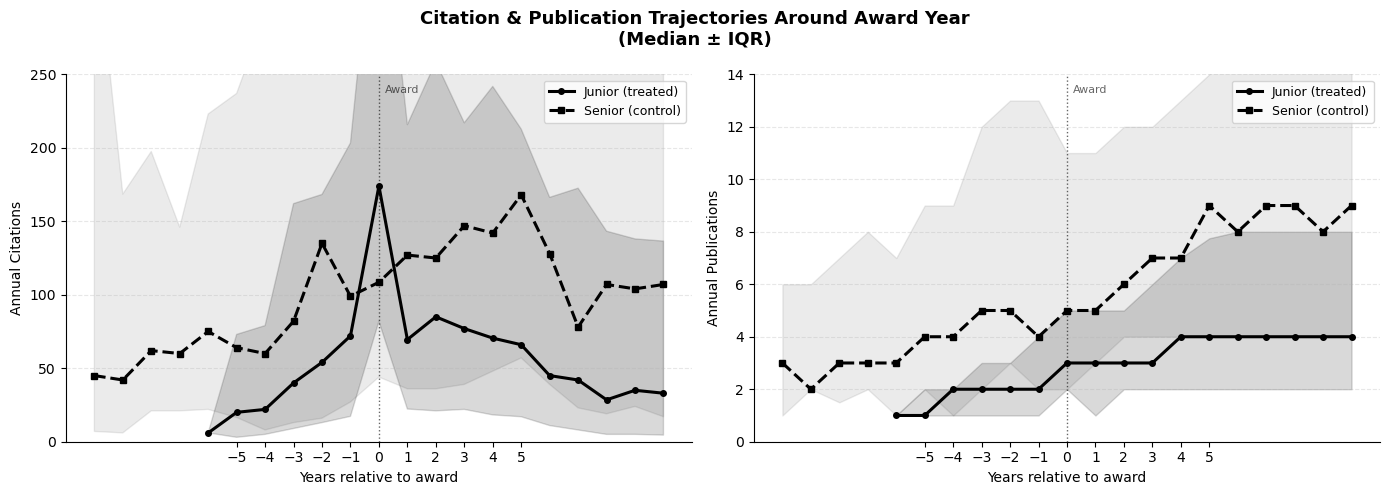

In [14]:
import matplotlib.pyplot as plt
import numpy as np

traj = long.groupby(["treatment", "rel_year"]).agg(
    med_citations=("citations", "median"),
    med_works=("works", "median"),
    q25_cit=("citations", lambda x: x.quantile(0.25)),
    q75_cit=("citations", lambda x: x.quantile(0.75)),
    q25_works=("works", lambda x: x.quantile(0.25)),
    q75_works=("works", lambda x: x.quantile(0.75)),
).reset_index()

jun = traj[traj["treatment"] == 1]
sen = traj[traj["treatment"] == 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Citation & Publication Trajectories Around Award Year\n(Median ± IQR)",
             fontsize=13, fontweight="bold")

for ax, ycol, q25col, q75col, ylabel, ylim in [
    (axes[0], "med_citations", "q25_cit", "q75_cit", "Annual Citations",    (0, 250)),
    (axes[1], "med_works",     "q25_works","q75_works","Annual Publications",(0, 14)),
]:
    ax.fill_between(jun["rel_year"], jun[q25col], jun[q75col],
                    alpha=0.15, color="black")
    ax.fill_between(sen["rel_year"], sen[q25col], sen[q75col],
                    alpha=0.08, color="black")

    ax.plot(jun["rel_year"], jun[ycol], color="black",
            linewidth=2.2, marker="o", markersize=4, label="Junior (treated)")
    ax.plot(sen["rel_year"], sen[ycol], color="black",
            linewidth=2.2, marker="s", markersize=4, linestyle="--", label="Senior (control)")

    ax.set_ylim(ylim)
    ax.axvline(0, color="black", linewidth=1.0, linestyle=":", alpha=0.6)
    ax.text(0.2, ax.get_ylim()[1] * 0.95, "Award", fontsize=8, alpha=0.6)

    ax.set_xlabel("Years relative to award", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xticks(range(-5, 6))
    ax.legend(fontsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig(DATA_FIGURES / "11_lift_trajectories.png", dpi=150, bbox_inches="tight")
print("✓ Saved: 11_lift_trajectories.png")
plt.show()


✓ Saved: 11_lift_distributions.png


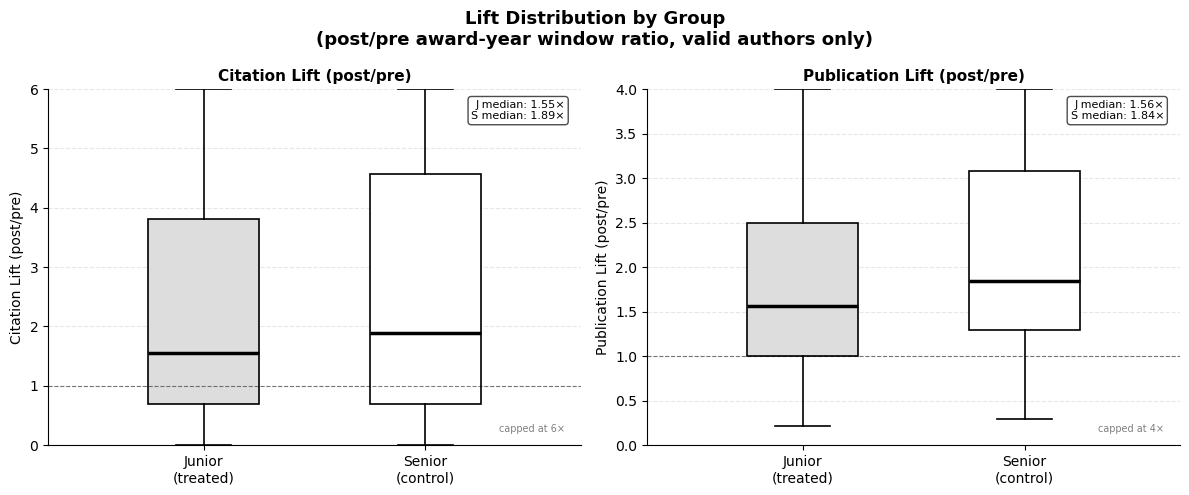

In [16]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Lift Distribution by Group\n(post/pre award-year window ratio, valid authors only)",
             fontsize=13, fontweight="bold")

juniors = authors_valid[authors_valid["treatment"] == 1]
seniors = authors_valid[authors_valid["treatment"] == 0]

for ax, metric, cap, ylabel in [
    (axes[0], "lift_citations", 6,  "Citation Lift (post/pre)"),
    (axes[1], "lift_works",     4,  "Publication Lift (post/pre)"),
]:
    jvals = juniors[metric].clip(upper=cap).dropna().values
    svals = seniors[metric].clip(upper=cap).dropna().values

    bp = ax.boxplot(
        [jvals, svals],
        positions=[1, 2],
        widths=0.5,
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2.5),
        whiskerprops=dict(color="black", linewidth=1.2),
        capprops=dict(color="black", linewidth=1.2),
        boxprops=dict(linewidth=1.2),
        flierprops=dict(marker="o", markersize=2, alpha=0.3, color="black"),
    )

    bp["boxes"][0].set_facecolor("#dddddd")
    bp["boxes"][1].set_facecolor("white")

    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Junior\n(treated)", "Senior\n(control)"])
    ax.set_xlim(0.3, 2.7)
    ax.axhline(1.0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_ylim(0, cap)          # ← AFTER axhline
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(ylabel, fontsize=11, fontweight="bold")
    ax.text(0.97, 0.97,
            f"J median: {juniors[metric].median():.2f}×\nS median: {seniors[metric].median():.2f}×",
            transform=ax.transAxes, fontsize=8, va="top", ha="right",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black", alpha=0.7))
    ax.text(0.97, 0.03, f"capped at {cap}×",
            transform=ax.transAxes, fontsize=7, va="bottom", ha="right", alpha=0.5)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig(DATA_FIGURES / "11_lift_distributions.png", dpi=150, bbox_inches="tight")
print("✓ Saved: 11_lift_distributions.png")
plt.show()
